## Fire Detection Pipeline (ResNet18)

## 1. Setup & Konfiguration


In [1]:
# Imports
import os
import time
import shutil
from pathlib import Path
from collections import OrderedDict, Counter
from functools import partial
from random import randint, sample
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# Pfade
DFIRE_DIR = "./D-Fire"                       # Originales D-Fire Dataset (YOLO-Format)
OUTPUT_DIR = "./classification_dataset/train"      # Output Preprocessing
MODEL_SAVE_PATH = "./best_model.pth"         # Checkpoint des besten Modells
PLOT_SAVE_PATH = "./training_plot.png"       # Trainings-Plot

# Preprocessing 
CLASS_MAP = {0: "fire", 1: "smoke"}
MIN_CROP_SIZE = 32

# Daten / Transforms 
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training-Hyperparameter 
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.2
NUM_WORKERS = 0  

In [3]:
# Device automatisch wählen (MPS / CUDA / CPU)
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS (Metal Performance Shaders)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA ({torch.cuda.get_device_name(0)})")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()

Using Apple MPS (Metal Performance Shaders)


## 3. Dataset & DataLoader

Transforms (Resize, Augmentation, Normalisierung) und Train/Val-Split.

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),  # 50% Wahrscheinlichkeit
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def get_dataloaders(data_dir: str, batch_size: int = 32,
                    val_split: float = 0.2, num_workers: int = 0):
    print(data_dir)
    full_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
    class_names = full_dataset.classes
    n_classes = len(class_names)
    n_val = int(len(full_dataset) * val_split)
    n_train = len(full_dataset) - n_val
    generator = torch.Generator().manual_seed(42)
    train_set, val_set = random_split(full_dataset, [n_train, n_val], generator=generator)
    # After the random_split, make a clean copy for counterfactual use
    cf_set = datasets.ImageFolder(data_dir, transform=val_transforms)  # no augmentation
    cf_train_set, _ = random_split(cf_set, [n_train, n_val], generator=generator)  # same split

    val_set.dataset = datasets.ImageFolder(data_dir, transform=val_transforms)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                            num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

    print(f"Dataset : {data_dir}")
    print(f"Classes : {n_classes}  {class_names}")
    print(f"Train   : {n_train}   Val: {n_val}")

    return train_loader, val_loader, cf_train_set, class_names, n_classes  # ← added cf_train_set

## 4. Modell — ResNet18

Eigene ResNet-Implementierung mit Encoder (Residual Blocks) + Decoder (Global Avg Pool + FC).

In [5]:
class Conv2dAuto(nn.Conv2d):
    """Conv2d mit automatischem 'same' Padding basierend auf der Kernel-Größe."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)


conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)


class ResidualBlock(nn.Module):
    """Basis Residual Block: output = blocks(x) + shortcut(x)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.blocks = nn.Identity()
        self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels


class ResNetResidualBlock(ResidualBlock):
    """ResNet Residual Block mit Expansion und optionalem Downsampling."""
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion = expansion
        self.downsampling = downsampling
        self.conv = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn': nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )

    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels


def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    """Convolution gefolgt von BatchNorm."""
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn': nn.BatchNorm2d(out_channels)
    }))


class ResNetBasicBlock(ResNetResidualBlock):
    """Basic Block: zwei 3x3 conv/bn Layer mit ReLU."""
    expansion = 1

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, conv=self.conv,
                    bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, conv=self.conv, bias=False),
        )


class ResNetBottleNeckBlock(ResNetResidualBlock):
    """Bottleneck Block: 1x1 -> 3x3 -> 1x1 conv/bn Layer."""
    expansion = 4

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, expansion=4, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, self.conv, kernel_size=1),
            activation(),
            conv_bn(self.out_channels, self.out_channels, self.conv,
                    kernel_size=3, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, self.conv, kernel_size=1),
        )

In [6]:
class ResNetLayer(nn.Module):
    """Ein Layer, bestehend aus n gestapelten Residual Blocks."""
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock, n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs, downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )

    def forward(self, x):
        return self.blocks(x)


class ResNetEncoder(nn.Module):
    """ResNet Encoder: Gate (7x7 conv + pool) gefolgt von Residual Layers."""
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes

        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])

    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x


class ResNetDecoder(nn.Module):
    """Global Average Pool gefolgt von Fully Connected Classifier."""
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)

    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x


class ResNet(nn.Module):
    """Komplettes ResNet: Encoder + Decoder."""
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Factory Functions
def resnet18(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[2, 2, 2, 2])

def resnet34(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[3, 4, 6, 3])

def resnet50(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 4, 6, 3])

def resnet101(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 4, 23, 3])

def resnet152(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 8, 36, 3])

# 7. **Modell Laden für Counterfactuals**

./best_model.pth
./classification_dataset/train
Dataset : ./classification_dataset/train
Classes : 2  ['fire', 'no_fire']
Train   : 13777   Val: 3444
Query Label: 0 (fire) | Konfidenz: 0.9830
CF Target: 1 (no_fire)
MAD
13777
NO MAD
Seed 0
λ-Schleife 
0
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 0 | λ=0.0100 | Schritt 000 | Loss: 0.0408 | Pred: fire


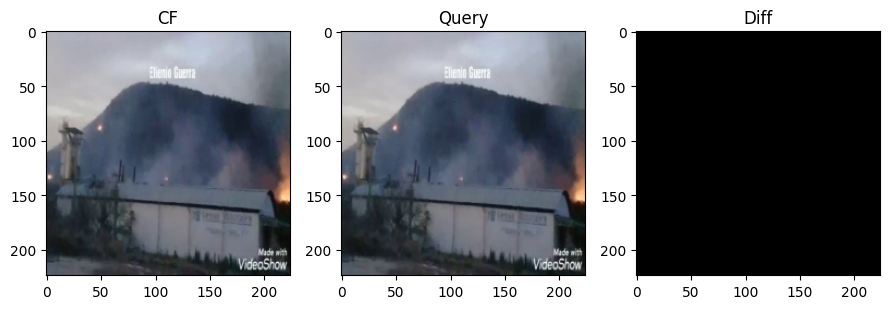

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001830, cls=2.7107, dist=0.001294
  Schritt 2: probs[fire]=0.7771, probs[no_fire]=0.2229, delta_mean=0.002616, cls=1.5009, dist=0.002364
  Schritt 3: probs[fire]=0.4807, probs[no_fire]=0.5193, delta_mean=0.003342, cls=0.6554, dist=0.003376
  Schritt 4: probs[fire]=0.2143, probs[no_fire]=0.7857, delta_mean=0.003952, cls=0.2411, dist=0.004310
  Schritt 5: probs[fire]=0.0856, probs[no_fire]=0.9144, delta_mean=0.004441, cls=0.0895, dist=0.005090
✓ Zielklasse erreicht | Seed 0 | λ=0.0100 | Schritt 5
λ-Schleife 
1
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 0 | λ=0.0150 | Schritt 000 | Loss: 0.0611 | Pred: fire


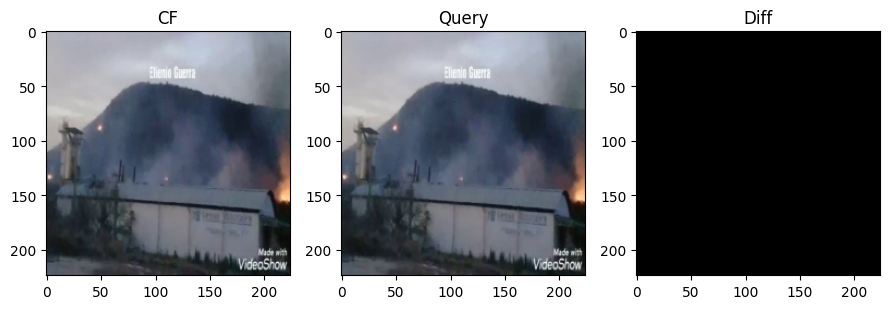

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001863, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7762, probs[no_fire]=0.2238, delta_mean=0.002682, cls=1.4972, dist=0.002409
  Schritt 3: probs[fire]=0.4778, probs[no_fire]=0.5222, delta_mean=0.003447, cls=0.6497, dist=0.003467
  Schritt 4: probs[fire]=0.2107, probs[no_fire]=0.7893, delta_mean=0.004106, cls=0.2366, dist=0.004453
  Schritt 5: probs[fire]=0.0828, probs[no_fire]=0.9172, delta_mean=0.004653, cls=0.0864, dist=0.005298
✓ Zielklasse erreicht | Seed 0 | λ=0.0150 | Schritt 5
λ-Schleife 
2
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 0 | λ=0.0225 | Schritt 000 | Loss: 0.0917 | Pred: fire


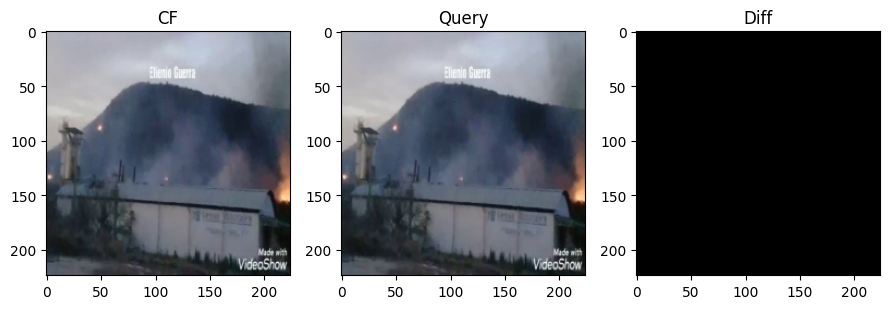

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001884, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7758, probs[no_fire]=0.2242, delta_mean=0.002727, cls=1.4954, dist=0.002439
  Schritt 3: probs[fire]=0.4764, probs[no_fire]=0.5236, delta_mean=0.003519, cls=0.6470, dist=0.003530
  Schritt 4: probs[fire]=0.2089, probs[no_fire]=0.7911, delta_mean=0.004212, cls=0.2343, dist=0.004552
  Schritt 5: probs[fire]=0.0814, probs[no_fire]=0.9186, delta_mean=0.004802, cls=0.0849, dist=0.005444
✓ Zielklasse erreicht | Seed 0 | λ=0.0225 | Schritt 5
λ-Schleife 
3
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 0 | λ=0.0338 | Schritt 000 | Loss: 0.1376 | Pred: fire


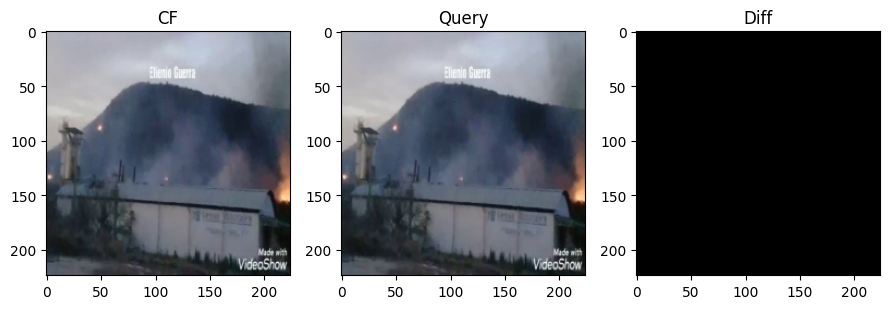

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001899, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7757, probs[no_fire]=0.2243, delta_mean=0.002757, cls=1.4946, dist=0.002459
  Schritt 3: probs[fire]=0.4757, probs[no_fire]=0.5243, delta_mean=0.003566, cls=0.6456, dist=0.003572
  Schritt 4: probs[fire]=0.2080, probs[no_fire]=0.7920, delta_mean=0.004284, cls=0.2332, dist=0.004618
  Schritt 5: probs[fire]=0.0806, probs[no_fire]=0.9194, delta_mean=0.004904, cls=0.0841, dist=0.005545
✓ Zielklasse erreicht | Seed 0 | λ=0.0338 | Schritt 5
λ-Schleife 
4
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 0 | λ=0.0506 | Schritt 000 | Loss: 0.2064 | Pred: fire


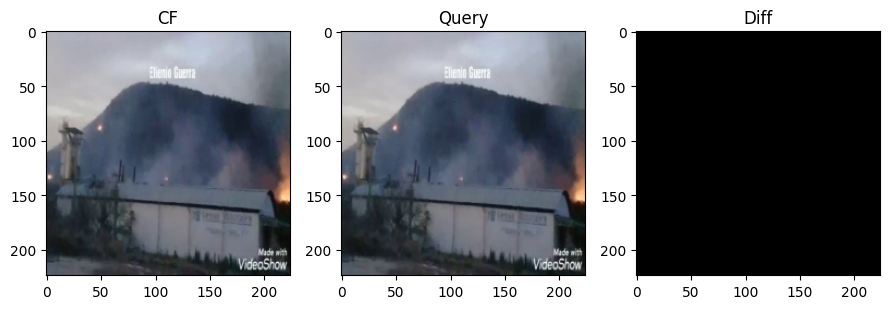

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001909, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7756, probs[no_fire]=0.2244, delta_mean=0.002778, cls=1.4942, dist=0.002473
  Schritt 3: probs[fire]=0.4753, probs[no_fire]=0.5247, delta_mean=0.003599, cls=0.6449, dist=0.003601
  Schritt 4: probs[fire]=0.2075, probs[no_fire]=0.7925, delta_mean=0.004334, cls=0.2326, dist=0.004665
  Schritt 5: probs[fire]=0.0802, probs[no_fire]=0.9198, delta_mean=0.004975, cls=0.0836, dist=0.005614
✓ Zielklasse erreicht | Seed 0 | λ=0.0506 | Schritt 5
λ-Schleife 
5
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 0 | λ=0.0759 | Schritt 000 | Loss: 0.3096 | Pred: fire


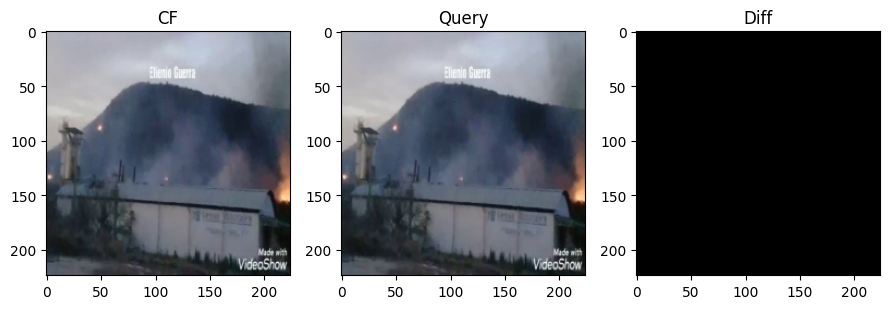

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001915, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002791, cls=1.4940, dist=0.002482
  Schritt 3: probs[fire]=0.4751, probs[no_fire]=0.5249, delta_mean=0.003621, cls=0.6445, dist=0.003619
  Schritt 4: probs[fire]=0.2073, probs[no_fire]=0.7927, delta_mean=0.004366, cls=0.2323, dist=0.004695
  Schritt 5: probs[fire]=0.0800, probs[no_fire]=0.9200, delta_mean=0.005022, cls=0.0834, dist=0.005659
✓ Zielklasse erreicht | Seed 0 | λ=0.0759 | Schritt 5
λ-Schleife 
6
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 0 | λ=0.1139 | Schritt 000 | Loss: 0.4644 | Pred: fire


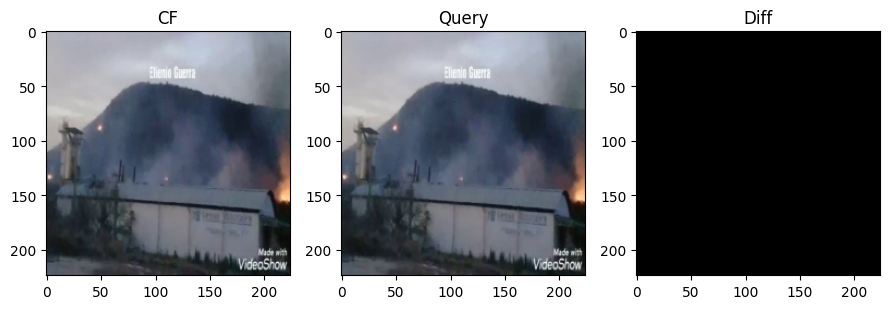

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001919, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002799, cls=1.4939, dist=0.002488
  Schritt 3: probs[fire]=0.4750, probs[no_fire]=0.5250, delta_mean=0.003634, cls=0.6443, dist=0.003632
  Schritt 4: probs[fire]=0.2072, probs[no_fire]=0.7928, delta_mean=0.004387, cls=0.2322, dist=0.004714
  Schritt 5: probs[fire]=0.0799, probs[no_fire]=0.9201, delta_mean=0.005053, cls=0.0833, dist=0.005689
✓ Zielklasse erreicht | Seed 0 | λ=0.1139 | Schritt 5
λ-Schleife 
7
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 0 | λ=0.1709 | Schritt 000 | Loss: 0.6965 | Pred: fire


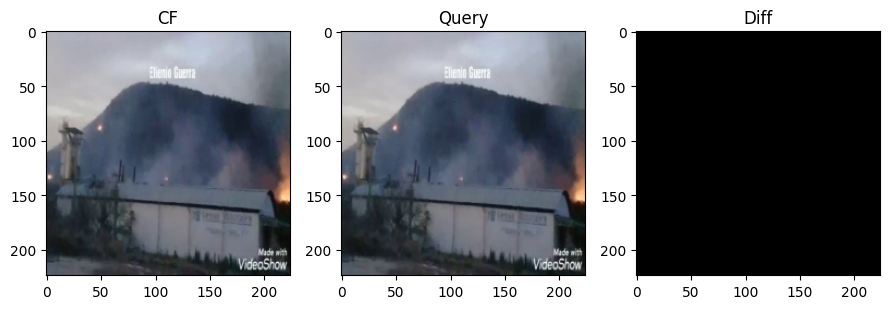

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001921, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002805, cls=1.4938, dist=0.002491
  Schritt 3: probs[fire]=0.4749, probs[no_fire]=0.5251, delta_mean=0.003644, cls=0.6442, dist=0.003640
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004402, cls=0.2321, dist=0.004728
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005074, cls=0.0832, dist=0.005710
✓ Zielklasse erreicht | Seed 0 | λ=0.1709 | Schritt 5
λ-Schleife 
8
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 0 | λ=0.2563 | Schritt 000 | Loss: 1.0448 | Pred: fire


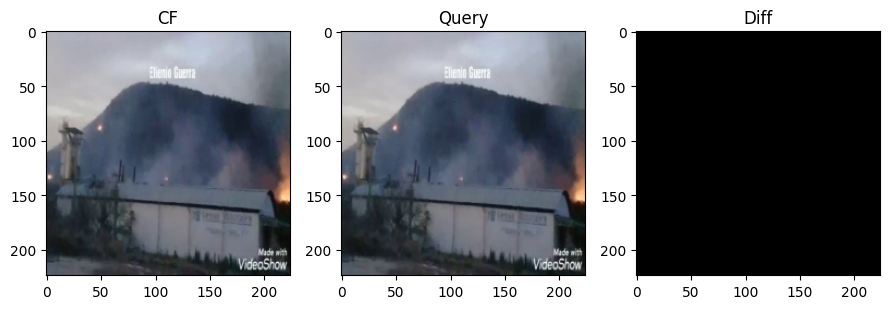

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001923, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002809, cls=1.4938, dist=0.002494
  Schritt 3: probs[fire]=0.4749, probs[no_fire]=0.5251, delta_mean=0.003650, cls=0.6441, dist=0.003645
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004411, cls=0.2320, dist=0.004736
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005087, cls=0.0831, dist=0.005723
✓ Zielklasse erreicht | Seed 0 | λ=0.2563 | Schritt 5
λ-Schleife 
9
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 0 | λ=0.3844 | Schritt 000 | Loss: 1.5672 | Pred: fire


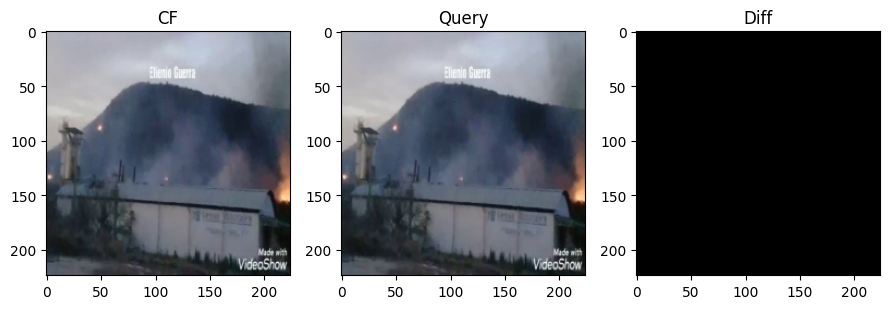

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001924, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002811, cls=1.4938, dist=0.002495
  Schritt 3: probs[fire]=0.4748, probs[no_fire]=0.5252, delta_mean=0.003654, cls=0.6441, dist=0.003648
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004417, cls=0.2320, dist=0.004742
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005096, cls=0.0831, dist=0.005732
✓ Zielklasse erreicht | Seed 0 | λ=0.3844 | Schritt 5
→ Neues bestes CF | Seed 0 | Distanz: 862.7533
Seed 42
λ-Schleife 
0
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 42 | λ=0.0100 | Schritt 000 | Loss: 0.0408 | Pred: fire


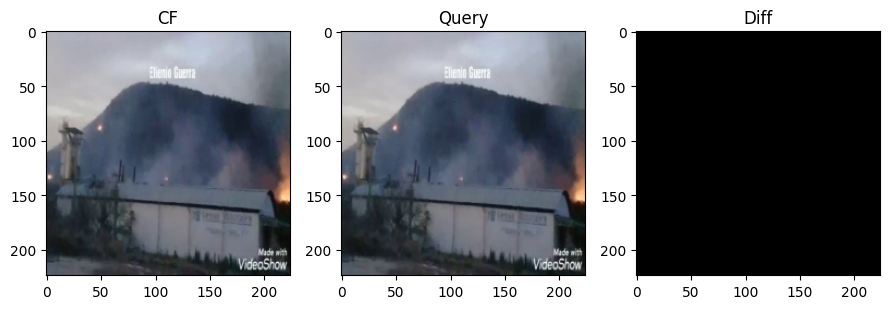

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001830, cls=2.7107, dist=0.001294
  Schritt 2: probs[fire]=0.7771, probs[no_fire]=0.2229, delta_mean=0.002616, cls=1.5009, dist=0.002364
  Schritt 3: probs[fire]=0.4807, probs[no_fire]=0.5193, delta_mean=0.003342, cls=0.6554, dist=0.003376
  Schritt 4: probs[fire]=0.2143, probs[no_fire]=0.7857, delta_mean=0.003952, cls=0.2411, dist=0.004310
  Schritt 5: probs[fire]=0.0856, probs[no_fire]=0.9144, delta_mean=0.004441, cls=0.0895, dist=0.005090
✓ Zielklasse erreicht | Seed 42 | λ=0.0100 | Schritt 5
λ-Schleife 
1
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 42 | λ=0.0150 | Schritt 000 | Loss: 0.0611 | Pred: fire


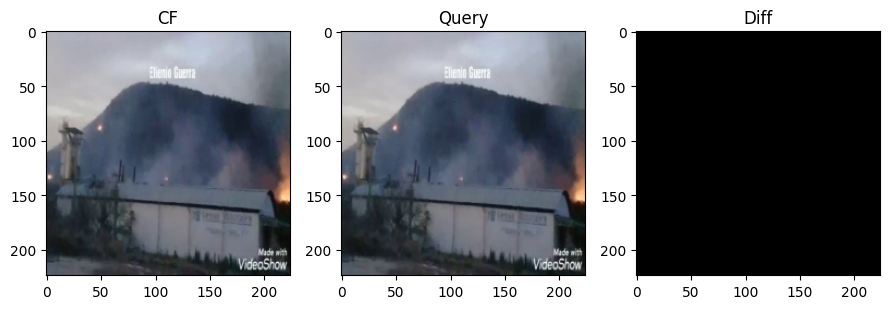

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001863, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7762, probs[no_fire]=0.2238, delta_mean=0.002682, cls=1.4972, dist=0.002409
  Schritt 3: probs[fire]=0.4778, probs[no_fire]=0.5222, delta_mean=0.003447, cls=0.6497, dist=0.003467
  Schritt 4: probs[fire]=0.2107, probs[no_fire]=0.7893, delta_mean=0.004106, cls=0.2366, dist=0.004453
  Schritt 5: probs[fire]=0.0828, probs[no_fire]=0.9172, delta_mean=0.004653, cls=0.0864, dist=0.005298
✓ Zielklasse erreicht | Seed 42 | λ=0.0150 | Schritt 5
λ-Schleife 
2
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 42 | λ=0.0225 | Schritt 000 | Loss: 0.0917 | Pred: fire


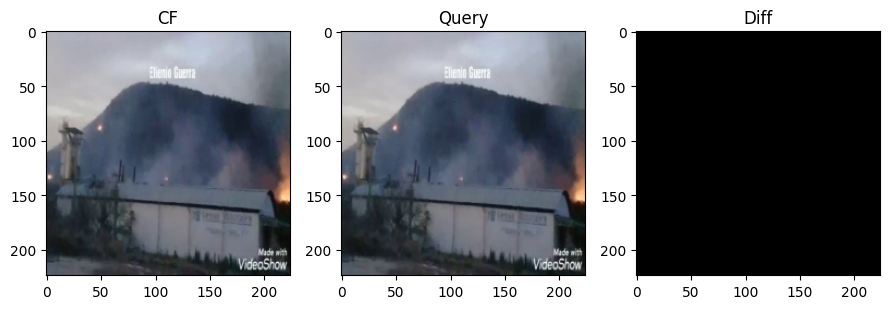

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001884, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7758, probs[no_fire]=0.2242, delta_mean=0.002727, cls=1.4954, dist=0.002439
  Schritt 3: probs[fire]=0.4764, probs[no_fire]=0.5236, delta_mean=0.003519, cls=0.6470, dist=0.003530
  Schritt 4: probs[fire]=0.2089, probs[no_fire]=0.7911, delta_mean=0.004212, cls=0.2343, dist=0.004552
  Schritt 5: probs[fire]=0.0814, probs[no_fire]=0.9186, delta_mean=0.004802, cls=0.0849, dist=0.005444
✓ Zielklasse erreicht | Seed 42 | λ=0.0225 | Schritt 5
λ-Schleife 
3
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 42 | λ=0.0338 | Schritt 000 | Loss: 0.1376 | Pred: fire


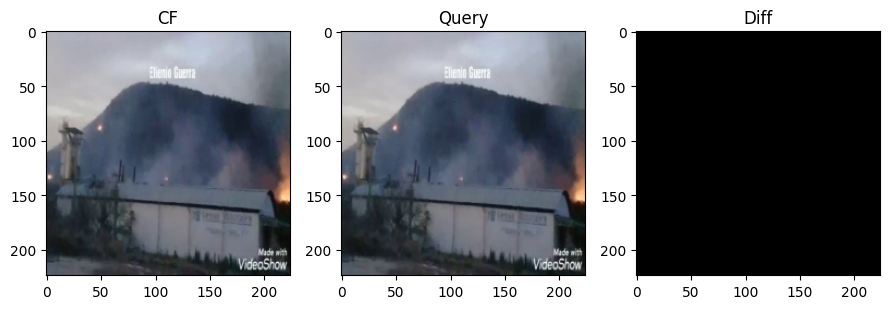

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001899, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7757, probs[no_fire]=0.2243, delta_mean=0.002757, cls=1.4946, dist=0.002459
  Schritt 3: probs[fire]=0.4757, probs[no_fire]=0.5243, delta_mean=0.003566, cls=0.6456, dist=0.003572
  Schritt 4: probs[fire]=0.2080, probs[no_fire]=0.7920, delta_mean=0.004284, cls=0.2332, dist=0.004618
  Schritt 5: probs[fire]=0.0806, probs[no_fire]=0.9194, delta_mean=0.004904, cls=0.0841, dist=0.005545
✓ Zielklasse erreicht | Seed 42 | λ=0.0338 | Schritt 5
λ-Schleife 
4
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 42 | λ=0.0506 | Schritt 000 | Loss: 0.2064 | Pred: fire


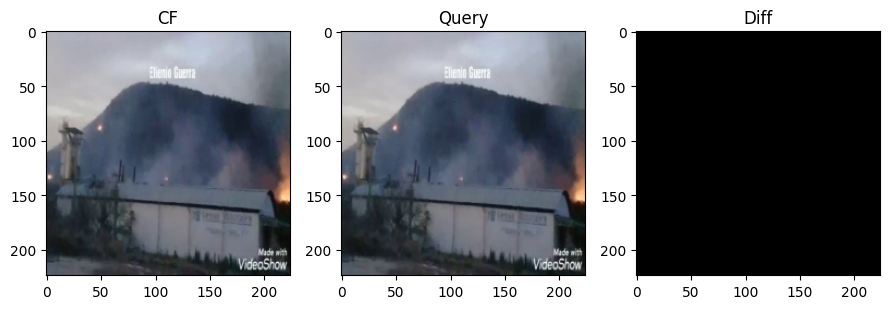

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001909, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7756, probs[no_fire]=0.2244, delta_mean=0.002778, cls=1.4942, dist=0.002473
  Schritt 3: probs[fire]=0.4753, probs[no_fire]=0.5247, delta_mean=0.003599, cls=0.6449, dist=0.003601
  Schritt 4: probs[fire]=0.2075, probs[no_fire]=0.7925, delta_mean=0.004334, cls=0.2326, dist=0.004665
  Schritt 5: probs[fire]=0.0802, probs[no_fire]=0.9198, delta_mean=0.004975, cls=0.0836, dist=0.005614
✓ Zielklasse erreicht | Seed 42 | λ=0.0506 | Schritt 5
λ-Schleife 
5
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 42 | λ=0.0759 | Schritt 000 | Loss: 0.3096 | Pred: fire


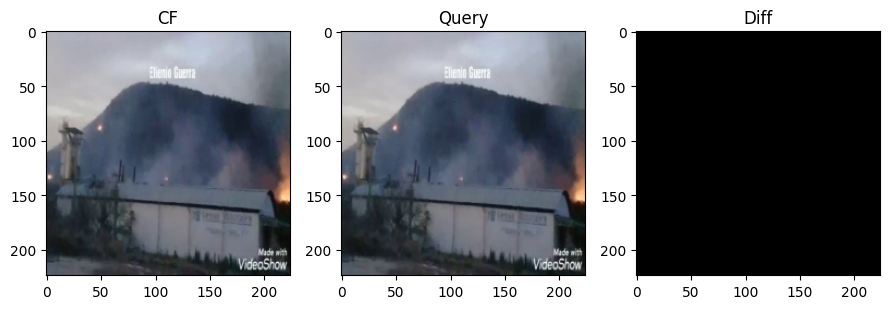

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001915, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002791, cls=1.4940, dist=0.002482
  Schritt 3: probs[fire]=0.4751, probs[no_fire]=0.5249, delta_mean=0.003621, cls=0.6445, dist=0.003619
  Schritt 4: probs[fire]=0.2073, probs[no_fire]=0.7927, delta_mean=0.004366, cls=0.2323, dist=0.004695
  Schritt 5: probs[fire]=0.0800, probs[no_fire]=0.9200, delta_mean=0.005022, cls=0.0834, dist=0.005659
✓ Zielklasse erreicht | Seed 42 | λ=0.0759 | Schritt 5
λ-Schleife 
6
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 42 | λ=0.1139 | Schritt 000 | Loss: 0.4644 | Pred: fire


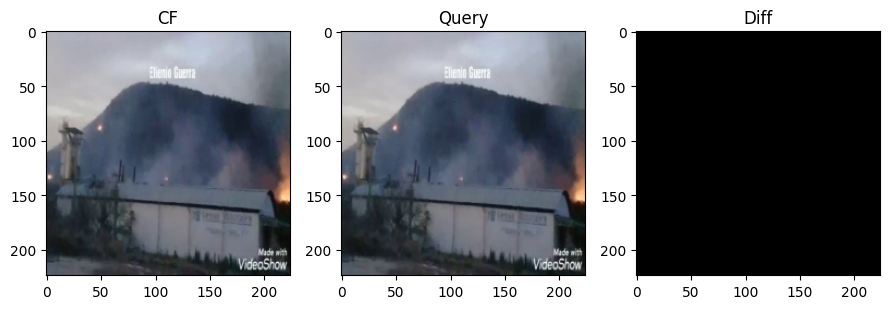

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001919, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002799, cls=1.4939, dist=0.002488
  Schritt 3: probs[fire]=0.4750, probs[no_fire]=0.5250, delta_mean=0.003634, cls=0.6443, dist=0.003632
  Schritt 4: probs[fire]=0.2072, probs[no_fire]=0.7928, delta_mean=0.004387, cls=0.2322, dist=0.004714
  Schritt 5: probs[fire]=0.0799, probs[no_fire]=0.9201, delta_mean=0.005053, cls=0.0833, dist=0.005689
✓ Zielklasse erreicht | Seed 42 | λ=0.1139 | Schritt 5
λ-Schleife 
7
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 42 | λ=0.1709 | Schritt 000 | Loss: 0.6965 | Pred: fire


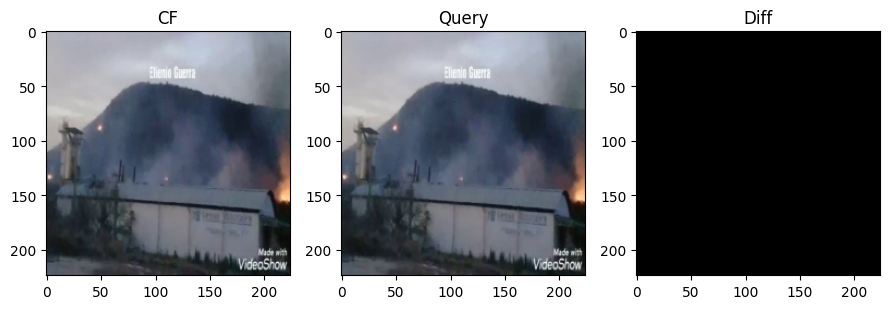

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001921, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002805, cls=1.4938, dist=0.002491
  Schritt 3: probs[fire]=0.4749, probs[no_fire]=0.5251, delta_mean=0.003644, cls=0.6442, dist=0.003640
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004402, cls=0.2321, dist=0.004728
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005074, cls=0.0832, dist=0.005710
✓ Zielklasse erreicht | Seed 42 | λ=0.1709 | Schritt 5
λ-Schleife 
8
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 42 | λ=0.2563 | Schritt 000 | Loss: 1.0448 | Pred: fire


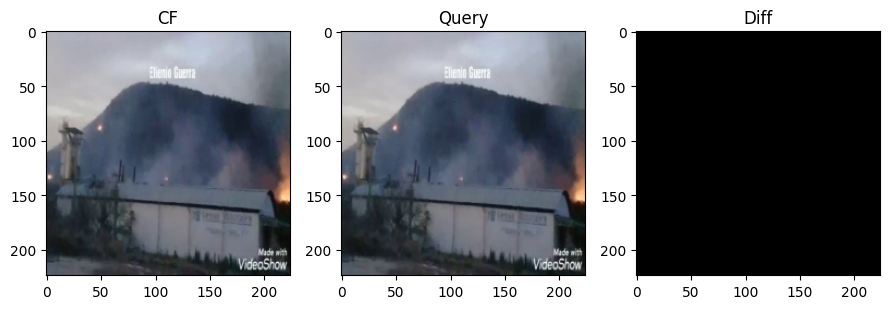

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001923, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002809, cls=1.4938, dist=0.002494
  Schritt 3: probs[fire]=0.4749, probs[no_fire]=0.5251, delta_mean=0.003650, cls=0.6441, dist=0.003645
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004411, cls=0.2320, dist=0.004736
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005087, cls=0.0831, dist=0.005723
✓ Zielklasse erreicht | Seed 42 | λ=0.2563 | Schritt 5
λ-Schleife 
9
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 42 | λ=0.3844 | Schritt 000 | Loss: 1.5672 | Pred: fire


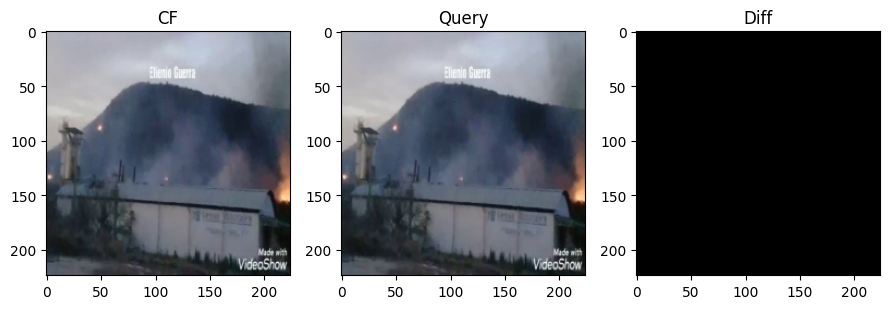

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001924, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002811, cls=1.4938, dist=0.002495
  Schritt 3: probs[fire]=0.4748, probs[no_fire]=0.5252, delta_mean=0.003654, cls=0.6441, dist=0.003648
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004417, cls=0.2320, dist=0.004742
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005096, cls=0.0831, dist=0.005732
✓ Zielklasse erreicht | Seed 42 | λ=0.3844 | Schritt 5
Seed 123
λ-Schleife 
0
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 123 | λ=0.0100 | Schritt 000 | Loss: 0.0408 | Pred: fire


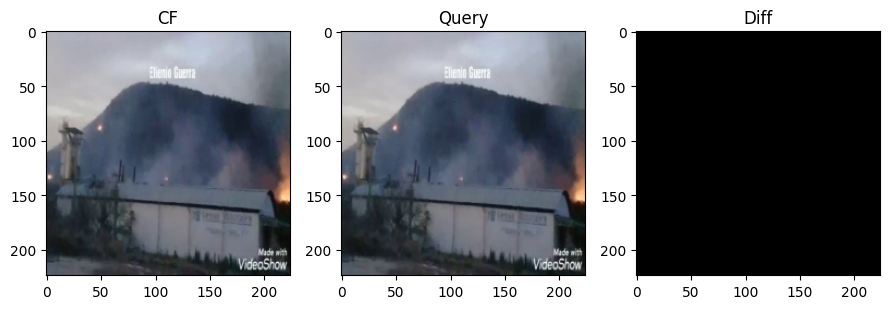

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001830, cls=2.7107, dist=0.001294
  Schritt 2: probs[fire]=0.7771, probs[no_fire]=0.2229, delta_mean=0.002616, cls=1.5009, dist=0.002364
  Schritt 3: probs[fire]=0.4807, probs[no_fire]=0.5193, delta_mean=0.003342, cls=0.6554, dist=0.003376
  Schritt 4: probs[fire]=0.2143, probs[no_fire]=0.7857, delta_mean=0.003952, cls=0.2411, dist=0.004310
  Schritt 5: probs[fire]=0.0856, probs[no_fire]=0.9144, delta_mean=0.004441, cls=0.0895, dist=0.005090
✓ Zielklasse erreicht | Seed 123 | λ=0.0100 | Schritt 5
λ-Schleife 
1
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 123 | λ=0.0150 | Schritt 000 | Loss: 0.0611 | Pred: fire


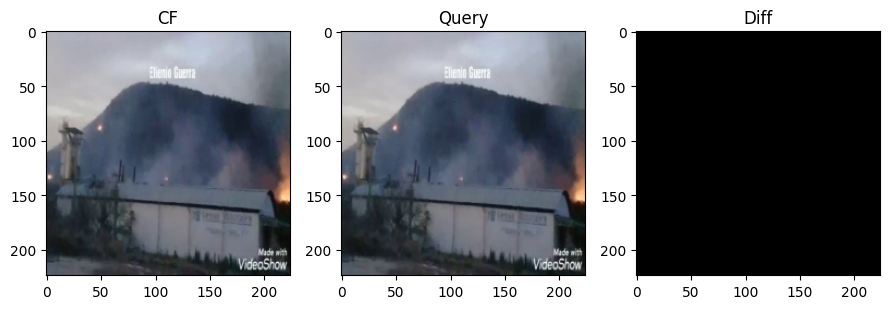

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001863, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7762, probs[no_fire]=0.2238, delta_mean=0.002682, cls=1.4972, dist=0.002409
  Schritt 3: probs[fire]=0.4778, probs[no_fire]=0.5222, delta_mean=0.003447, cls=0.6497, dist=0.003467
  Schritt 4: probs[fire]=0.2107, probs[no_fire]=0.7893, delta_mean=0.004106, cls=0.2366, dist=0.004453
  Schritt 5: probs[fire]=0.0828, probs[no_fire]=0.9172, delta_mean=0.004653, cls=0.0864, dist=0.005298
✓ Zielklasse erreicht | Seed 123 | λ=0.0150 | Schritt 5
λ-Schleife 
2
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.000999, cls=4.0766, dist=0.000000
Seed 123 | λ=0.0225 | Schritt 000 | Loss: 0.0917 | Pred: fire


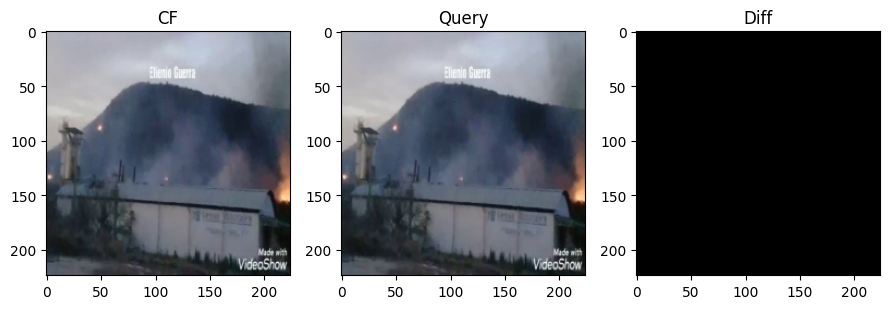

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001884, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7758, probs[no_fire]=0.2242, delta_mean=0.002727, cls=1.4954, dist=0.002439
  Schritt 3: probs[fire]=0.4764, probs[no_fire]=0.5236, delta_mean=0.003519, cls=0.6470, dist=0.003530
  Schritt 4: probs[fire]=0.2089, probs[no_fire]=0.7911, delta_mean=0.004212, cls=0.2343, dist=0.004552
  Schritt 5: probs[fire]=0.0814, probs[no_fire]=0.9186, delta_mean=0.004802, cls=0.0849, dist=0.005444
✓ Zielklasse erreicht | Seed 123 | λ=0.0225 | Schritt 5
λ-Schleife 
3
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 123 | λ=0.0338 | Schritt 000 | Loss: 0.1376 | Pred: fire


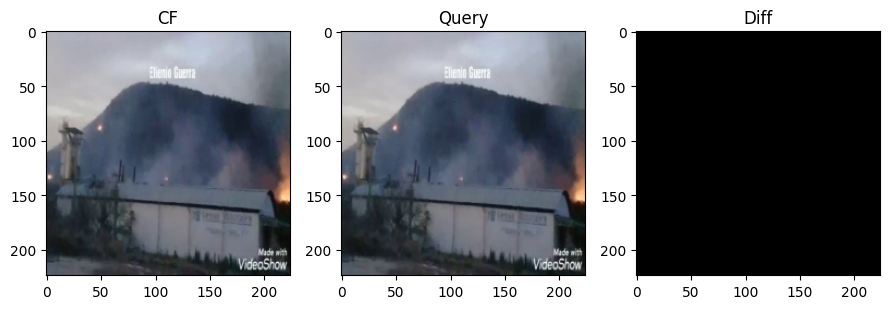

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001899, cls=2.7106, dist=0.001294
  Schritt 2: probs[fire]=0.7757, probs[no_fire]=0.2243, delta_mean=0.002757, cls=1.4946, dist=0.002459
  Schritt 3: probs[fire]=0.4757, probs[no_fire]=0.5243, delta_mean=0.003566, cls=0.6456, dist=0.003572
  Schritt 4: probs[fire]=0.2080, probs[no_fire]=0.7920, delta_mean=0.004284, cls=0.2332, dist=0.004618
  Schritt 5: probs[fire]=0.0806, probs[no_fire]=0.9194, delta_mean=0.004904, cls=0.0841, dist=0.005545
✓ Zielklasse erreicht | Seed 123 | λ=0.0338 | Schritt 5
λ-Schleife 
4
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 123 | λ=0.0506 | Schritt 000 | Loss: 0.2064 | Pred: fire


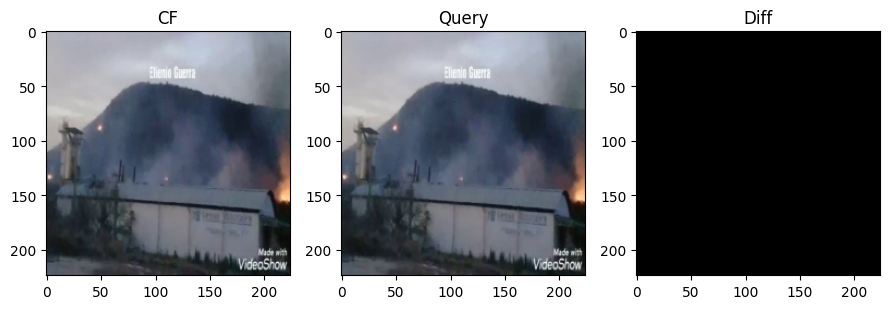

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001909, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7756, probs[no_fire]=0.2244, delta_mean=0.002778, cls=1.4942, dist=0.002473
  Schritt 3: probs[fire]=0.4753, probs[no_fire]=0.5247, delta_mean=0.003599, cls=0.6449, dist=0.003601
  Schritt 4: probs[fire]=0.2075, probs[no_fire]=0.7925, delta_mean=0.004334, cls=0.2326, dist=0.004665
  Schritt 5: probs[fire]=0.0802, probs[no_fire]=0.9198, delta_mean=0.004975, cls=0.0836, dist=0.005614
✓ Zielklasse erreicht | Seed 123 | λ=0.0506 | Schritt 5
λ-Schleife 
5
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 123 | λ=0.0759 | Schritt 000 | Loss: 0.3096 | Pred: fire


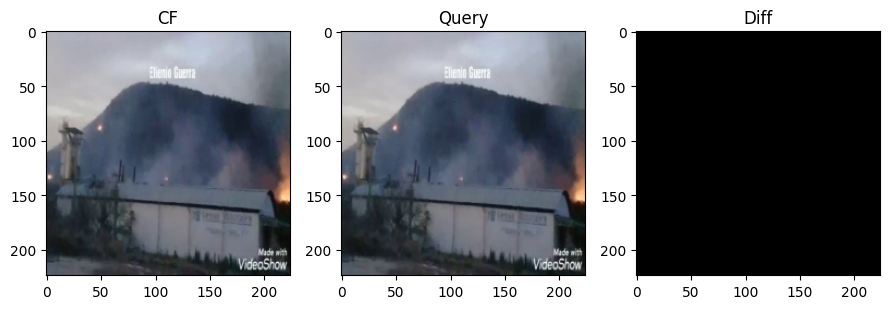

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001915, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002791, cls=1.4940, dist=0.002482
  Schritt 3: probs[fire]=0.4751, probs[no_fire]=0.5249, delta_mean=0.003621, cls=0.6445, dist=0.003619
  Schritt 4: probs[fire]=0.2073, probs[no_fire]=0.7927, delta_mean=0.004366, cls=0.2323, dist=0.004695
  Schritt 5: probs[fire]=0.0800, probs[no_fire]=0.9200, delta_mean=0.005022, cls=0.0834, dist=0.005659
✓ Zielklasse erreicht | Seed 123 | λ=0.0759 | Schritt 5
λ-Schleife 
6
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 123 | λ=0.1139 | Schritt 000 | Loss: 0.4644 | Pred: fire


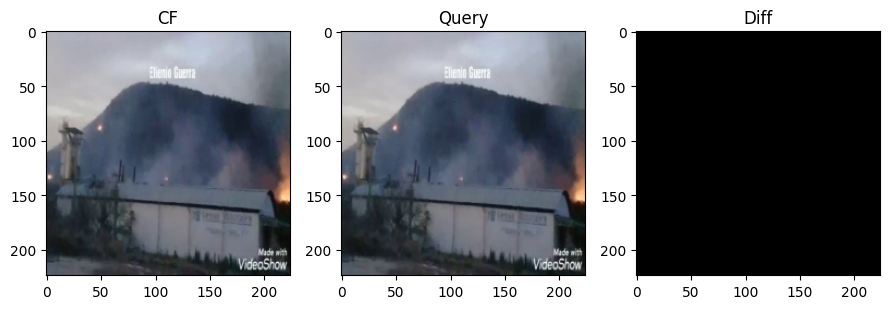

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001919, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002799, cls=1.4939, dist=0.002488
  Schritt 3: probs[fire]=0.4750, probs[no_fire]=0.5250, delta_mean=0.003634, cls=0.6443, dist=0.003632
  Schritt 4: probs[fire]=0.2072, probs[no_fire]=0.7928, delta_mean=0.004387, cls=0.2322, dist=0.004714
  Schritt 5: probs[fire]=0.0799, probs[no_fire]=0.9201, delta_mean=0.005053, cls=0.0833, dist=0.005689
✓ Zielklasse erreicht | Seed 123 | λ=0.1139 | Schritt 5
λ-Schleife 
7
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 123 | λ=0.1709 | Schritt 000 | Loss: 0.6965 | Pred: fire


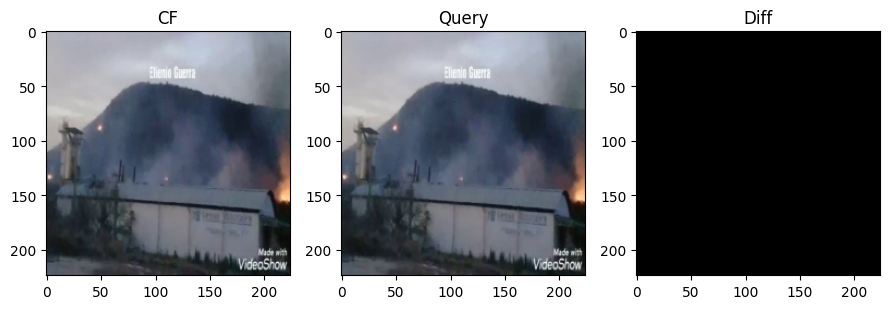

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001921, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002805, cls=1.4938, dist=0.002491
  Schritt 3: probs[fire]=0.4749, probs[no_fire]=0.5251, delta_mean=0.003644, cls=0.6442, dist=0.003640
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004402, cls=0.2321, dist=0.004728
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005074, cls=0.0832, dist=0.005710
✓ Zielklasse erreicht | Seed 123 | λ=0.1709 | Schritt 5
λ-Schleife 
8
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 123 | λ=0.2563 | Schritt 000 | Loss: 1.0448 | Pred: fire


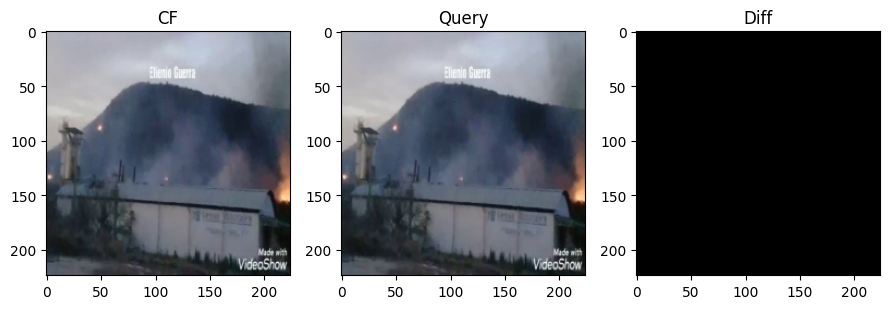

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001923, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002809, cls=1.4938, dist=0.002494
  Schritt 3: probs[fire]=0.4749, probs[no_fire]=0.5251, delta_mean=0.003650, cls=0.6441, dist=0.003645
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004411, cls=0.2320, dist=0.004736
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005087, cls=0.0831, dist=0.005723
✓ Zielklasse erreicht | Seed 123 | λ=0.2563 | Schritt 5
λ-Schleife 
9
  Schritt 0: probs[fire]=0.9830, probs[no_fire]=0.0170, delta_mean=0.001000, cls=4.0766, dist=0.000000
Seed 123 | λ=0.3844 | Schritt 000 | Loss: 1.5672 | Pred: fire


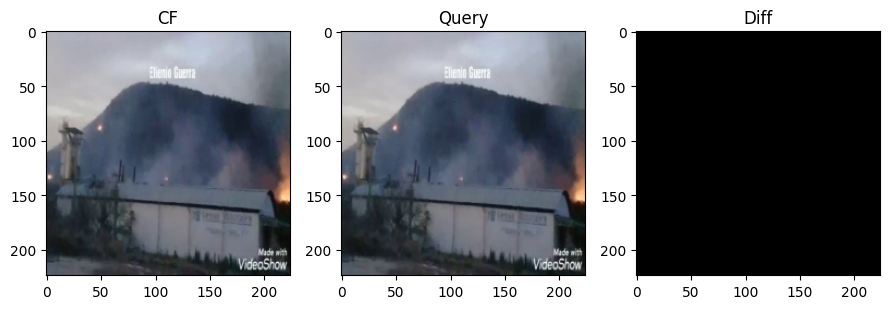

  Schritt 1: probs[fire]=0.9335, probs[no_fire]=0.0665, delta_mean=0.001924, cls=2.7105, dist=0.001295
  Schritt 2: probs[fire]=0.7755, probs[no_fire]=0.2245, delta_mean=0.002811, cls=1.4938, dist=0.002495
  Schritt 3: probs[fire]=0.4748, probs[no_fire]=0.5252, delta_mean=0.003654, cls=0.6441, dist=0.003648
  Schritt 4: probs[fire]=0.2071, probs[no_fire]=0.7929, delta_mean=0.004417, cls=0.2320, dist=0.004742
  Schritt 5: probs[fire]=0.0798, probs[no_fire]=0.9202, delta_mean=0.005096, cls=0.0831, dist=0.005732
✓ Zielklasse erreicht | Seed 123 | λ=0.3844 | Schritt 5

Bestes CF | Gesamtdistanz: 862.7533
Finale Vorhersage: no_fire


In [7]:
print(MODEL_SAVE_PATH)

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone().cpu()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

def load_model(path, device):
    global model
    model = resnet18(in_channels=3, n_classes=n_classes)
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model

# 1. Dataset & Modell laden 
train_loader, val_loader, cf_train_set, class_names, n_classes = get_dataloaders(
    data_dir=OUTPUT_DIR,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    num_workers=NUM_WORKERS
)
load_model(MODEL_SAVE_PATH, device)

# Gewichte einfrieren 
for param in model.parameters():
    param.requires_grad = False

# 2. Query-Bild wählen 
# Query-Sampling – nur Bilder wählen die das Modell korrekt und mit hoher Konfidenz klassifiziert
while True:
    query_image, query_label = cf_train_set[randint(0, len(cf_train_set) - 1)]
    query_image_dev = query_image.clone().to(device)
    
    with torch.no_grad():
        output = model(query_image_dev.unsqueeze(0))
        probs  = torch.softmax(output, dim=1)
        pred   = output.argmax().item()
        conf   = probs[0, query_label].item()
    
    # Modell muss das Query korrekt klassifizieren mit Konfidenz > 0.9
    if pred == query_label and conf > 0.9:
        break

query_image = query_image_dev
n_pixels    = query_image.numel()
print(f'Query Label: {query_label} ({class_names[query_label]}) | Konfidenz: {conf:.4f}')

cf_target = 1 - query_label
print(f'CF Target: {cf_target} ({class_names[cf_target]})')

# 3. MAD einmalig berechnen 
print("MAD")
print(len(cf_train_set))
sample_idx = sample(range(len(cf_train_set)), 1000)
all_pixels = torch.stack([cf_train_set[i][0] for i in sample_idx])
median     = all_pixels.median(dim=0).values
mad        = (all_pixels - median).abs().median(dim=0).values
mad        = mad.clamp(min=1e-6).to(device)
print("NO MAD")
# 4. Hyperparameter 
error                = nn.CrossEntropyLoss()
learning_rate        = 0.001
lambda_val           = 0.01
lambda_step          = 1.5
confidence_threshold = 0.8

seeds     = [0, 42, 123]
best_cf   = None
best_dist = float('inf')

#  5. Seed-Schleife (äußerste) 
for seed in seeds:
    torch.manual_seed(seed)
    lambda_val = 0.01  
    print('Seed', seed)
    #  6. λ-Schleife 
    for outer in range(10):
        print('λ-Schleife ')
        print(outer)
        delta = torch.zeros_like(query_image, requires_grad=True)
        optimizer_cf = torch.optim.Adam([delta], lr=learning_rate)

#  7. Optimierungsschleife (innerste) 
        for i in range(1000):
            optimizer_cf.zero_grad()
            cf_image = query_image + delta
            output   = model(cf_image.unsqueeze(0))
            probs    = torch.softmax(output, dim=1)
            dist    = ((cf_image - query_image).abs() / mad).sum() / n_pixels
            cls     = error(output, torch.tensor([cf_target]).to(device))
            loss_cf = lambda_val * cls + dist
            loss_cf.backward()
            optimizer_cf.step()

 
            if i < 15:
                print(f"  Schritt {i}: probs[fire]={probs[0,0].item():.4f}, "
                      f"probs[no_fire]={probs[0,1].item():.4f}, "
                      f"delta_mean={delta.abs().mean().item():.6f}, "
                      f"cls={cls.item():.4f}, dist={dist.item():.6f}")

            if i % 100 == 0:
                pred = output.argmax().item()
                print(f"Seed {seed} | λ={lambda_val:.4f} | Schritt {i:03d} | "
                      f"Loss: {loss_cf.item():.4f} | Pred: {class_names[pred]}")

                fig, axes = plt.subplots(1, 3, figsize=(9, 3))
                cf_np     = denormalize(cf_image.detach().cpu()).numpy()
                query_np  = denormalize(query_image.cpu()).numpy()
                diff_display = np.abs(cf_np - query_np)
                diff_display = diff_display - diff_display.min()
                if diff_display.max() > 0:
                    diff_display = diff_display / diff_display.max()

                def to_display(t):
                    return t[0] if t.shape[0] == 1 else t.transpose(1, 2, 0)

                axes[0].imshow(to_display(cf_np));    axes[0].set_title("CF")
                axes[1].imshow(to_display(query_np)); axes[1].set_title("Query")
                axes[2].imshow(to_display(diff_display)); axes[2].set_title("Diff")
                plt.tight_layout()
                plt.show()

            if probs[0, cf_target].item() >= confidence_threshold:
                print(f"✓ Zielklasse erreicht | Seed {seed} | λ={lambda_val:.4f} | Schritt {i}")
                break

        lambda_val *= lambda_step

    #  8. Bestes CF speichern 
    current_dist = ((cf_image - query_image).abs() / mad).sum().item()
    if current_dist < best_dist:
        best_dist = current_dist
        best_cf   = cf_image.detach().clone()
        print(f"→ Neues bestes CF | Seed {seed} | Distanz: {best_dist:.4f}")

print(f"\nBestes CF | Gesamtdistanz: {best_dist:.4f}")
print(f"Finale Vorhersage: {class_names[model(best_cf.unsqueeze(0)).argmax().item()]}")